In [27]:
!pip install chromadb

In [44]:
import os
import getpass
import chromadb
from chromadb.api.types import Documents, EmbeddingFunction, Embeddings
from pypdf import PdfReader
from fpdf import FPDF
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Official Google GenAI SDK
from google import genai
from google.genai import types

# Force-install/upgrade numpy, ignoring the system-installed version to ensure Python 3.13 compatibility (numpy 2.x)
!pip install -q --upgrade --ignore-installed numpy

# Force-uninstall pandas and pyarrow, then reinstall pyarrow first, then pandas,
# to resolve potential internal pandas inconsistencies and the PYARROW_INSTALLED error.
!pip uninstall -y pandas pyarrow
!pip install -q pyarrow
!pip install -q pandas

# Now install other necessary packages, which should resolve dependencies against the newly installed core libraries
!pip install -q --force-reinstall google-genai chromadb pypdf fpdf langchain-text-splitters scipy nltk matplotlib seaborn

# Secure Gemini API Key Ingestion
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass.getpass("🔑 Enter your Google Gemini API Key: ")
    os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

# Initialize Client
client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Google Gemini API Client initialized successfully!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
bigframes 2.48.0 requires rich<14,>=12.4.4, but you have rich 15.0.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.
Found existing installation: pandas 3.0.5
Uninstalling pandas-3.0.5:
  Successfully uninstalled pandas-3.0.5
Found existing installation: pyarr

In [29]:
# CELL 1: GENERATE SYNTHETIC KNOWLEDGE BASE (PDF)
# Run this cell to create a dummy HR Policy PDF for our live ingestion demo.

pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

document_text = """Acme Corp Global Employee Handbook (2026)

1. Remote Work Policy:
Employees may work remotely up to 3 days per week. Tuesdays and Thursdays are designated 'Anchor Days' where in-office presence is mandatory for collaborative meetings. Core working hours are 10:00 AM to 3:00 PM local time.

2. Annual Leave and PTO:
Full-time employees accrue 20 days of Paid Time Off (PTO) annually. Up to 5 unused PTO days can be rolled over to the next calendar year. Rollover days expire on March 31st.

3. Cloud Infrastructure Security:
All database access requires VPN connection and Multi-Factor Authentication (MFA). Database passwords must be rotated every 60 days. API keys must never be hardcoded into Git repositories.

4. Expense Reimbursements:
Business travel expenses must be submitted within 30 days of the trip via the Concur portal. Meal allowances are capped at $75 per diem. Alcohol is not a reimbursable expense.

5. Hardware Upgrades:
Engineers are eligible for a laptop refresh every 3 years. The standard issue is a 16-inch M-series MacBook Pro. Monitor allowance for home offices is $500.
"""

for line in document_text.split('\n'):
    pdf.cell(200, 10, txt=line, ln=True, align='L')

pdf_filename = "Acme_HR_Policy_2026.pdf"
pdf.output(pdf_filename)
print(f"✅ Generated synthetic PDF document: '{pdf_filename}'")

✅ Generated synthetic PDF document: 'Acme_HR_Policy_2026.pdf'


### SECTION 1: EMBEDDINGS & SIMILARITY METRICS

1. EMBEDDINGS FOR RETRIEVAL:
   - An embedding converts raw unstructured text into a dense array of floating-point numbers (e.g., 768 dimensions for Gemini text-embedding-004).
   - In this high-dimensional space, semantically similar sentences are physically closer together.
   - Example: "The dog barked" and "A puppy yelped" have no overlapping keywords, but their embeddings will have high similarity.

2. SIMILARITY METRICS:
   - Cosine Similarity: Measures the angle between two vectors (1.0 = identical direction, 0.0 = orthogonal).
     Standard for text because it ignores vector magnitude (document length).
   - Dot Product: Computes angle AND magnitude. If vectors are normalized (L2=1), Dot Product == Cosine Similarity.
   - Euclidean Distance (L2): Measures straight-line distance. Sensitive to document length.


In [45]:
def compute_cosine_similarity(vec_a, vec_b):
    dot = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    return dot / (norm_a * norm_b)

# Fetch embeddings for a query and two documents
resp = client.models.embed_content(
    model="gemini-embedding-001",
    contents=["Refund my money", "I want my cash back", "The server is down"]
)
vectors = [emb.values for emb in resp.embeddings]

sim_1 = compute_cosine_similarity(vectors[0], vectors[1])
sim_2 = compute_cosine_similarity(vectors[0], vectors[2])

print("=== 🧮 COSINE SIMILARITY DEMONSTRATION ===")
print(f"Query: 'Refund my money'")
print(f"Similarity to 'I want my cash back': {sim_1:.4f} (High Semantic Affinity)")
print(f"Similarity to 'The server is down':  {sim_2:.4f} (Low Semantic Affinity)")

=== 🧮 COSINE SIMILARITY DEMONSTRATION ===
Query: 'Refund my money'
Similarity to 'I want my cash back': 0.7256 (High Semantic Affinity)
Similarity to 'The server is down':  0.5584 (Low Semantic Affinity)


In [46]:
import chromadb
from chromadb.api.types import Documents, EmbeddingFunction, Embeddings

# Let's define our Custom Gemini Embedding Function for ChromaDB
class GeminiEmbeddingFunction(EmbeddingFunction):
    def __init__(self):
        pass # No initialization needed for this simple case

    def __call__(self, input: Documents) -> Embeddings:
        response = client.models.embed_content(
            model="gemini-embedding-001",
            contents=input
        )
        # Return a list of float arrays
        return [emb.values for emb in response.embeddings]

gemini_ef = GeminiEmbeddingFunction()
print("✅ Custom Gemini Embedding Function for ChromaDB registered.")

✅ Custom Gemini Embedding Function for ChromaDB registered.


### SECTION 3: LIVE DEMO — END-TO-END DOCUMENT INGESTION PIPELINE

In [47]:
# Step 1: Extract Text from PDF
reader = PdfReader("Acme_HR_Policy_2026.pdf")
raw_text = ""
for page in reader.pages:
    raw_text += page.extract_text() + "\n"

print("1. PDF Loaded & Parsed.")

# Step 2: Recursive Character Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,      # Max characters per chunk
    chunk_overlap=40,    # Context overlap
    separators=["\n\n", "\n", ".", " "]
)
chunks = text_splitter.split_text(raw_text)
print(f"2. Document Split into {len(chunks)} contextual chunks.")

# Step 3: Initialize ChromaDB and Ingest Data
chroma_client = chromadb.Client()

# Create or reset the collection
collection_name = "acme_hr_policy"
try:
    chroma_client.delete_collection(collection_name)
except:
    pass
collection = chroma_client.create_collection(
    name=collection_name,
    embedding_function=gemini_ef
)

# Prepare lists for Chroma
documents = []
ids = []
metadatas = []

for i, chunk in enumerate(chunks):
    documents.append(chunk)
    ids.append(f"chunk_{i}")
    metadatas.append({"source": "Acme_HR_Policy_2026.pdf", "chunk_index": i})

# Add to Vector Database (This automatically calls the Gemini Embedding API)
print("3. Embedding chunks and indexing in ChromaDB... (Please wait ~3 seconds)")
collection.add(
    documents=documents,
    ids=ids,
    metadatas=metadatas
)
print("✅ Ingestion Complete! Vector DB is ready for queries.")

1. PDF Loaded & Parsed.
2. Document Split into 9 contextual chunks.
3. Embedding chunks and indexing in ChromaDB... (Please wait ~3 seconds)
✅ Ingestion Complete! Vector DB is ready for queries.


### SECTION 4: LIVE DEMO — RETRIEVAL & SEMANTIC SEARCH

In [48]:
# Now we act as the user asking a question
user_query = "What happens to my unused vacation days at the end of the year?"

print(f"👤 USER QUERY: '{user_query}'\n")

# Query ChromaDB (Embeds the query, does cosine similarity search, returns Top K)
results = collection.query(
    query_texts=[user_query],
    n_results=2 # Top-k retrieval
)

print("=== 🔍 VECTOR DB RETRIEVAL RESULTS ===")
for i, (doc, meta, distance) in enumerate(zip(results["documents"][0], results["metadatas"][0], results["distances"][0])):
    # Note: Chroma uses L2 distance by default. Lower is better/closer.
    print(f"\n--- Rank {i+1} (Distance: {distance:.4f}) ---")
    print(f"Source: {meta['source']} (Chunk {meta['chunk_index']})")
    print(f"Text Content:\n{doc}")

👤 USER QUERY: 'What happens to my unused vacation days at the end of the year?'

=== 🔍 VECTOR DB RETRIEVAL RESULTS ===

--- Rank 1 (Distance: 0.5856) ---
Source: Acme_HR_Policy_2026.pdf (Chunk 3)
Text Content:
2. Annual Leave and PTO:
Full-time employees accrue 20 days of Paid Time Off (PTO) annually. Up to 5 unused PTO days can be rolled over to the next calendar year. Rollover days expire on March 31st.

--- Rank 2 (Distance: 0.9046) ---
Source: Acme_HR_Policy_2026.pdf (Chunk 8)
Text Content:
5. Hardware Upgrades:
Engineers are eligible for a laptop refresh every 3 years. The standard issue is a 16-inch M-series MacBook Pro. Monitor allowance for home offices is $500.


THE NEXT STEP (RAG GENERATION):
In a full RAG pipeline, we take these retrieved chunks and inject them into the LLM prompt:
"Answer the user query using ONLY the following context: <chunk_1> <chunk_2>. Query: What happens..."
(We will cover the generation half deeply tomorrow!)


### SECTION 5: RAG VS. FINE-TUNING DECISION FRAMEWORK

THE MOST COMMON INDUSTRY CONFUSION: "Should I Fine-Tune or use RAG?"

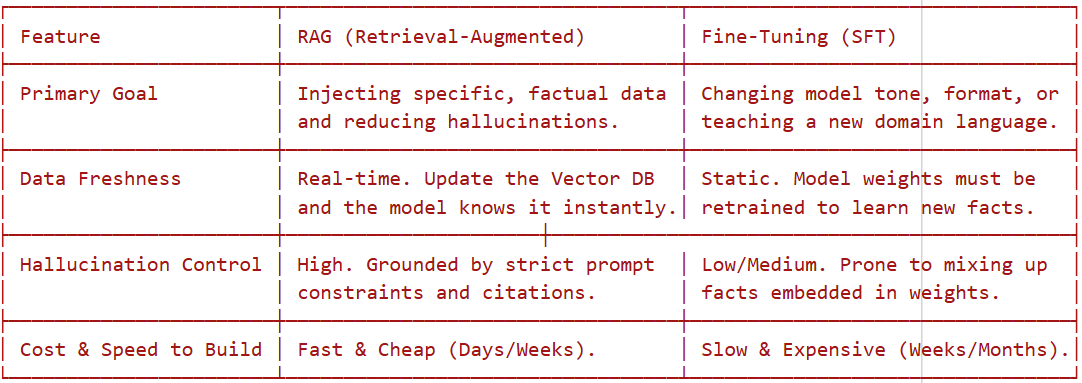

RULE OF THUMB:
1. If the model needs to know NEW FACTS -> Use RAG.
2. If the model needs to learn a NEW SKILL or TONE -> Use Fine-Tuning.
3. If both -> Do Both (Fine-Tune for format, RAG for facts).


### SECTION 6: STUDENT GRADED LAB — INGESTION & RETRIEVAL

🎓 STUDENT LAB INSTRUCTIONS:
You are building the retrieval engine for an IT Support Knowledge Base.

MANDATORY TASKS:
1. Review the provided string variable `it_knowledge_base`.
2. Use the LangChain `RecursiveCharacterTextSplitter` to chunk the text.
   - Set chunk_size = 150
   - Set chunk_overlap = 25
3. Create a NEW ChromaDB collection named "it_support_kb".
4. Ingest your chunks, ids, and metadata into the collection.
5. Run the 3 test queries below and print the top 1 result for each.

it_knowledge_base = """
IT Support Troubleshooting Guide:

1. VPN Connection Failures:
If Cisco AnyConnect fails with 'Connection Timeout', ensure the user is not on a public hotel Wi-Fi network that blocks UDP port 443. Instruct the user to switch to a mobile hotspot.

2. Printer Installation:
To map the 3rd floor marketing printer, users must connect to the corporate network, open File Explorer, type '\\printserver01\MKTG_Color_Laser', and double-click to install drivers automatically.

3. Account Lockouts:
Active Directory accounts lock out after 5 invalid password attempts. The lockout duration is 30 minutes. Helpdesk agents can manually unlock accounts via the Azure Admin Portal after verifying the employee's PIN.


In [49]:
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)

# 1. Chunking
it_text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=25,
    separators=["\n\n", "\n", ".", " "]
)
it_chunks = it_text_splitter.split_text(it_knowledge_base)
print(f"IT Knowledge Base split into {len(it_chunks)} chunks.")

# 2. Create a NEW ChromaDB collection named 'it_support_kb'
# 3. Ingest chunks, ids, and metadata

it_collection_name = "it_support_kb"
try:
    chroma_client.delete_collection(it_collection_name)
except:
    pass
it_collection = chroma_client.create_collection(
    name=it_collection_name,
    embedding_function=gemini_ef
)

it_documents = []
it_ids = []
it_metadatas = []

for i, chunk in enumerate(it_chunks):
    it_documents.append(chunk)
    it_ids.append(f"it_chunk_{i}")
    it_metadatas.append({"source": "IT_Knowledge_Base", "chunk_index": i})

print("Embedding IT chunks and indexing in ChromaDB...")
it_collection.add(
    documents=it_documents,
    ids=it_ids,
    metadatas=it_metadatas
)
print("✅ IT Support KB Ingestion Complete!")

IT Knowledge Base split into 11 chunks.
Embedding IT chunks and indexing in ChromaDB...
✅ IT Support KB Ingestion Complete!


In [50]:
# 4. Run the 3 test queries below and print the top 1 result for each.

# Test Query 1
query_1 = "My VPN is not connecting. What should I do?"
print(f"\n👤 USER QUERY 1: '{query_1}'")
results_1 = it_collection.query(query_texts=[query_1], n_results=1)
print("=== 🔍 VECTOR DB RETRIEVAL RESULT 1 ===")
for doc, meta, distance in zip(results_1["documents"][0], results_1["metadatas"][0], results_1["distances"][0]):
    print(f"\n--- Rank 1 (Distance: {distance:.4f}) ---")
    print(f"Source: {meta['source']} (Chunk {meta['chunk_index']})")
    print(f"Text Content:\n{doc}")

# Test Query 2
query_2 = "How do I install the marketing printer?"
print(f"\n👤 USER QUERY 2: '{query_2}'")
results_2 = it_collection.query(query_texts=[query_2], n_results=1)
print("=== 🔍 VECTOR DB RETRIEVAL RESULT 2 ===")
for doc, meta, distance in zip(results_2["documents"][0], results_2["metadatas"][0], results_2["distances"][0]):
    print(f"\n--- Rank 1 (Distance: {distance:.4f}) ---")
    print(f"Source: {meta['source']} (Chunk {meta['chunk_index']})")
    print(f"Text Content:\n{doc}")

# Test Query 3
query_3 = "My account is locked. How long will it be locked for?"
print(f"\n👤 USER QUERY 3: '{query_3}'")
results_3 = it_collection.query(query_texts=[query_3], n_results=1)
print("=== 🔍 VECTOR DB RETRIEVAL RESULT 3 ===")
for doc, meta, distance in zip(results_3["documents"][0], results_3["metadatas"][0], results_3["distances"][0]):
    print(f"\n--- Rank 1 (Distance: {distance:.4f}) ---")
    print(f"Source: {meta['source']} (Chunk {meta['chunk_index']})")
    print(f"Text Content:\n{doc}")


👤 USER QUERY 1: 'My VPN is not connecting. What should I do?'
=== 🔍 VECTOR DB RETRIEVAL RESULT 1 ===

--- Rank 1 (Distance: 0.4625) ---
Source: IT_Knowledge_Base (Chunk 1)
Text Content:
1. VPN Connection Failures:

👤 USER QUERY 2: 'How do I install the marketing printer?'
=== 🔍 VECTOR DB RETRIEVAL RESULT 2 ===

--- Rank 1 (Distance: 0.4453) ---
Source: IT_Knowledge_Base (Chunk 4)
Text Content:
2. Printer Installation:

👤 USER QUERY 3: 'My account is locked. How long will it be locked for?'
=== 🔍 VECTOR DB RETRIEVAL RESULT 3 ===

--- Rank 1 (Distance: 0.5070) ---
Source: IT_Knowledge_Base (Chunk 8)
Text Content:
3. Account Lockouts:


#**AGENTS**

In [1]:
!pip install -q -U google-genai tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 17.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [2]:
# CELL 0: ENVIRONMENT SETUP & GOOGLE GEMINI API AUTHENTICATION
# Run this cell first. Installs the official Google GenAI SDK.

import os
import getpass
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Modern Google GenAI SDK
from google import genai
from google.genai import types

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

# ------------------------------------------------------------------------------
# Secure Gemini API Key Ingestion
# ------------------------------------------------------------------------------
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass.getpass("🔑 Enter your Google Gemini API Key: ")
    os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

# Initialize Client
client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Google Gemini Agentic Client initialized successfully!")

✅ Google Gemini Agentic Client initialized successfully!


### SECTION 1: FROM CHATBOT TO AGENT (RESPONDING VS. ACTING)

THE EVOLUTION OF LLM APPLICATIONS:

1. Chatbot (Responding):
   - Confined to its training data context window.
   - Output: Text, code, or formatting.
   - Weakness: Cannot interact with the outside world, hallucinate recent facts, cannot take action.

2. Agent (Acting via Tool Calling):
   - Has a "brain" (LLM) connected to "hands" (Tools/Functions).
   - Can pause generation, request a function execution (e.g., run SQL, search the web, trigger an API),
     wait for the result, and synthesize the final answer.

--------------------------------------------------------------------------------
THE ReAct PATTERN (Reason + Act + Observe)
--------------------------------------------------------------------------------
Agents operate in a continuous cognitive loop developed by Princeton/Google researchers:
1. REASON (Thought): "The user wants to know Apple's current stock price and multiply it by 50."
2. ACT (Action): `get_stock_price(ticker="AAPL")`
3. OBSERVE (Observation): The function returns `150.25`.
4. REASON (Thought 2): "Now I need to multiply 150.25 by 50."
5. ACT (Action 2): `calculate(expression="150.25 * 50")`
6. OBSERVE (Observation 2): The function returns `7512.50`.
7. SYNTHESIZE: "If you buy 50 shares of AAPL, it will cost $7,512.50."

### SECTION 2: TOOL CALLING MECHANICS (DEFINING THE SCHEMA)

HOW THE MODEL DECIDES TO CALL A TOOL:
1. We pass a list of Python functions (or JSON schemas) in the API request configuration.
2. The LLM evaluates the user prompt against the descriptions of the provided tools.
3. If a tool is needed, the LLM stops returning standard text and instead returns a `FunctionCall`
   payload containing the function name and the extracted arguments (e.g., `{"ticker": "AAPL"}`).
4. The execution environment (your Python script) intercepts this, runs the actual code,
   and returns a `FunctionResponse` back to the LLM.
5. The LLM reads the result and resumes answering.

NOTE: Python Type Hints and Docstrings are MANDATORY! Gemini uses them to build the tool schema automatically.


In [3]:
# Tool 1: Live Database Lookup Simulation
def get_customer_balance(customer_id: str) -> float:
    """Looks up a customer's current account balance in the database.

    Args:
        customer_id: The unique customer identifier (e.g., 'CUST-100').
    """
    print(f"\n⚙️  [SYSTEM LOG] Executing DB Query for {customer_id}...")
    # Simulated database
    db = {"CUST-100": 2500.50, "CUST-200": -450.00, "CUST-300": 0.0}
    return db.get(customer_id.upper(), 0.0)

# Tool 2: Live Calculator
def safe_calculator(expression: str) -> float:
    """Evaluates a mathematical expression and returns the numeric result.

    Args:
        expression: A valid mathematical string (e.g., '2500.50 * 0.05').
    """
    print(f"⚙️  [SYSTEM LOG] Calculating: {expression}...")
    try:
        # In production, NEVER use raw eval(). Use safe parsers (e.g., numexpr or AST).
        return float(eval(expression))
    except Exception as e:
        return 0.0

print("✅ Tools defined: get_customer_balance, safe_calculator")

✅ Tools defined: get_customer_balance, safe_calculator


### SECTION 3: LIVE DEMO — MULTI-STEP TASK DECOMPOSITION & EXECUTION TRACE

In [4]:
# We initialize an automated chat session. Gemini SDK handles the ReAct
# loop (calling the function and returning the result) automatically!

print("=== 🤖 INITIATING AGENTIC CHAT SESSION ===")

agent_chat = client.chats.create(
    model="gemini-3.6-flash",
    config=types.GenerateContentConfig(
        tools=[get_customer_balance, safe_calculator],
        temperature=0.0, # Deterministic temperature for tool calling!
    )
)

user_prompt = "What is the balance of CUST-100? If I apply a 7.5% interest rate to it, what will the new total be?"
print(f"👤 User: {user_prompt}\n")

# Send the message. The SDK will automatically pause, run the Python functions, and send the results back!
response = agent_chat.send_message(user_prompt)

print(f"\n🤖 Final Agent Output:\n{response.text}\n")


# TRACING THE MODEL's REASONING STEPS
print("=== 🔍 SYSTEM AUDIT: REASONING & EXECUTION TRACE ===")

# We iterate through the raw conversation history to see what the model did behind the scenes.
for i, message in enumerate(agent_chat.get_history()):
    role_emoji = "👤 User" if message.role == "user" else "🤖 Model"
    print(f"Step {i+1} [{role_emoji}]:")

    for part in message.parts:
        # Check if the part is a standard text response
        if part.text:
            print(f"   [Text] -> {part.text.strip()}")

        # Check if the part is a request to call a tool
        elif part.function_call:
            print(f"   [Action Requested] -> {part.function_call.name}({part.function_call.args})")

        # Check if the part is the execution result returned to the model
        elif part.function_response:
            print(f"   [Observation Received] -> {part.function_response.name}: {part.function_response.response}")
    print("-" * 50)

=== 🤖 INITIATING AGENTIC CHAT SESSION ===
👤 User: What is the balance of CUST-100? If I apply a 7.5% interest rate to it, what will the new total be?


⚙️  [SYSTEM LOG] Executing DB Query for CUST-100...
⚙️  [SYSTEM LOG] Calculating: 2500.5 * 1.075...

🤖 Final Agent Output:
The current balance for **CUST-100** is **$2,500.50**.

Applying a 7.5% interest rate to this balance gives a new total of **$2,688.04** (calculated as $2,500.50 × 1.075 = $2,688.0375$).

=== 🔍 SYSTEM AUDIT: REASONING & EXECUTION TRACE ===
Step 1 [👤 User]:
   [Text] -> What is the balance of CUST-100? If I apply a 7.5% interest rate to it, what will the new total be?
--------------------------------------------------
Step 2 [🤖 Model]:
   [Action Requested] -> get_customer_balance({'customer_id': 'CUST-100'})
--------------------------------------------------
Step 3 [👤 User]:
   [Observation Received] -> get_customer_balance: {'result': 2500.5}
--------------------------------------------------
Step 4 [🤖 Model]:
   [

### SECTION 4: AGENTIC ORCHESTRATION, MEMORY, & GUARDRAILS

LANGCHAIN CORE COMPONENTS:
While you can build agents manually (as seen above), frameworks like LangChain abstract the boilerplate.
- Prompts: Templates for standardizing inputs.
- Chains: Hardcoded sequential pipes (Prompt -> Model -> Output Parser).
- Retrievers: Connections to Vector DBs for RAG.
- Agents: Dynamic chains where the LLM decides the routing flow based on tools.
- Trade-off: Frameworks speed up development but introduce heavy abstractions that can be hard to debug compared to raw API calls.

LANGGRAPH & MULTI-AGENT SYSTEMS:
- A state-machine approach to agents.
- Defines workflows as Graphs (Nodes = Agents/Tools, Edges = Routing Logic).
- Enables cycles (Agent A asks Agent B for code, Agent B writes it, Agent A tests it and sends it back if it fails).
- Introduces "Supervisor Agents" that delegate tasks to "Worker Agents".

GUARDRAILS & RUNAWAY LOOP PREVENTION:
1. Infinite Loop Prevention: An agent might call a failing tool over and over. Always implement `max_iterations` (e.g., force stop after 5 tool calls).
2. Cost Constraints: Tool loops consume massive tokens. Set budget caps.
3. Input/Output Filtering: Validate function arguments before execution to prevent Prompt Injection (e.g., a user prompt instructing the DB tool to run `DROP TABLE`).
4. Scope Limiting: Only give agents read-only tools unless operating in a highly trusted sandboxed environment.

### SECTION 5: STUDENT GRADED LAB — BUILD YOUR OWN TOOL

🎓 STUDENT LAB INSTRUCTIONS:
Build a working agent capable of fetching real-time/mock data using an external function.

MANDATORY TASKS:
1. Define a custom Python function with proper Type Hints and Docstrings.
   (e.g., `check_flight_status(flight_number: str)` or `get_inventory(product_id: int)`)
2. Create a Gemini Chat session injecting your custom tool into the `GenerateContentConfig`.
3. Send a user message that forces the model to use your tool to answer the question.
4. Extract and print the final text response.

In [5]:
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)


# 1. Define your custom tool (Function + Docstring)
def check_weather(city: str) -> str:
    """Fetches the current weather condition for a given city.

    Args:
        city: The name of the city (e.g., 'London', 'New York').
    """
    print(f"\n⚙️  [SYSTEM LOG] Checking weather for {city}...")
    # Simulated weather data
    weather_data = {
        "london": "Cloudy with a chance of rain, 15°C",
        "new york": "Sunny, 22°C",
        "tokyo": "Partly cloudy, 20°C",
        "paris": "Rainy, 13°C",
    }
    return weather_data.get(city.lower(), "Weather data not available for this city.")

# 2. Initialize Agent Chat Session
agent_chat_weather = client.chats.create(
    model="gemini-3.6-flash",
    config=types.GenerateContentConfig(
        tools=[check_weather],
        temperature=0.0,
    )
)

# 3. Trigger the Agent
user_prompt_weather = "What's the weather like in London?"
print(f"\n👤 User: {user_prompt_weather}\n")

response_weather = agent_chat_weather.send_message(user_prompt_weather)

# 4. Output the result
print(f"\n🤖 Final Agent Output:\n{response_weather.text}\n")


👤 User: What's the weather like in London?


⚙️  [SYSTEM LOG] Checking weather for London...

🤖 Final Agent Output:
The current weather in London is cloudy with a chance of rain, and the temperature is 15°C.

